In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('../data/processed/TMDB_clean.csv')
print(f"✅ Dataset cargado con {df.shape[0]} películas")

✅ Dataset cargado con 35029 películas


In [2]:
# Repetimos géneros para darles más peso en la comparación
df['Sinopsis'] = (
    df['overview'].fillna('') + ' ' +
    df['genres'].fillna('') + ' ' +
    df['director'].fillna('')
)

# Normalizamos el rating IMDB entre 0 y 1
scaler = MinMaxScaler()
df['imdb_rating_norm'] = scaler.fit_transform(df[['imdb_rating']])

print("Géneros e IMDB rating preparados")
df[['title', 'genres', 'imdb_rating', 'imdb_rating_norm']].head()

Géneros e IMDB rating preparados


,title,genres,imdb_rating,imdb_rating_norm
0,Ariel,"Comedy, Drama, Romance, Crime",7.4,0.756098
1,Shadows in Paradise,"Comedy, Drama, Romance",7.4,0.756098
2,Four Rooms,Comedy,6.7,0.670732
3,Judgment Night,"Action, Crime, Thriller",6.6,0.658537
4,Star Wars,"Adventure, Action, Science Fiction",8.6,0.902439


In [3]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
matriz_tfidf = tfidf.fit_transform(df['contenido'])

print(f"Matriz TF-IDF creada: {matriz_tfidf.shape}")

KeyError: 'contenido'

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
matriz_tfidf = tfidf.fit_transform(df['Sinopsis'])

print(f"✅ Matriz TF-IDF creada: {matriz_tfidf.shape}")

✅ Matriz TF-IDF creada: (35029, 5000)


In [5]:
similitud = cosine_similarity(matriz_tfidf, matriz_tfidf)
print(f" Matriz de similitud creada: {similitud.shape}")

 Matriz de similitud creada: (35029, 35029)


In [6]:
def recomendar_peliculas(titulo, n=10, min_imdb=6.0):
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    
    if titulo not in indices:
        return f"❌ Película '{titulo}' no encontrada"
    
    idx = indices[titulo]
    
    # Similitud por géneros
    puntajes = list(enumerate(similitud[idx]))
    puntajes = sorted(puntajes, key=lambda x: x[1], reverse=True)
    puntajes = puntajes[1:n*5+1]
    
    indices_peliculas = [i[0] for i in puntajes]
    
    # Filtrar por IMDB rating mínimo
    resultado = df[['title', 'genres', 'imdb_rating', 'release_year']].iloc[indices_peliculas]
    resultado = resultado[resultado['imdb_rating'] >= min_imdb]
    
    # Ordenar por IMDB rating de mayor a menor
    resultado = resultado.sort_values('imdb_rating', ascending=False)
    
    return resultado.head(n)

In [7]:
recomendaciones = recomendar_peliculas("Inception", n=10, min_imdb=6.0)
print("Películas recomendadas similares a Inception:")
recomendaciones

Películas recomendadas similares a Inception:


,title,genres,imdb_rating,release_year
19260,Guardians of the Galaxy,"Action, Science Fiction, Adventure",8.0,2014
101,"Crouching Tiger, Hidden Dragon","Adventure, Drama, Action, Romance",7.9,2000
12669,Awaara,"Drama, Music, Romance",7.8,1951
4273,Where Eagles Dare,"Action, Adventure, War",7.6,1968
11,The Fifth Element,"Science Fiction, Action, Adventure",7.6,1997
20366,Mission: Impossible - Rogue Nation,"Action, Adventure",7.4,2015
13597,The Twelve Months,"Fantasy, Animation, Family, Adventure",7.4,1956
15835,A Gentle Woman,"Romance, Drama",7.3,1969
28925,Tenet,"Action, Thriller, Science Fiction",7.3,2020
1423,The Country Girl,Drama,7.2,1954


In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Convertir la matriz TF-IDF a formato denso para K-Means
matriz_densa = matriz_tfidf.toarray()
print("✅ Matriz lista para K-Means")

✅ Matriz lista para K-Means


In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Convertir la matriz TF-IDF a formato denso para K-Means
matriz_densa = matriz_tfidf.toarray()
print("✅ Matriz lista para K-Means")

✅ Matriz lista para K-Means


✅ Matriz reducida: (35029, 100)


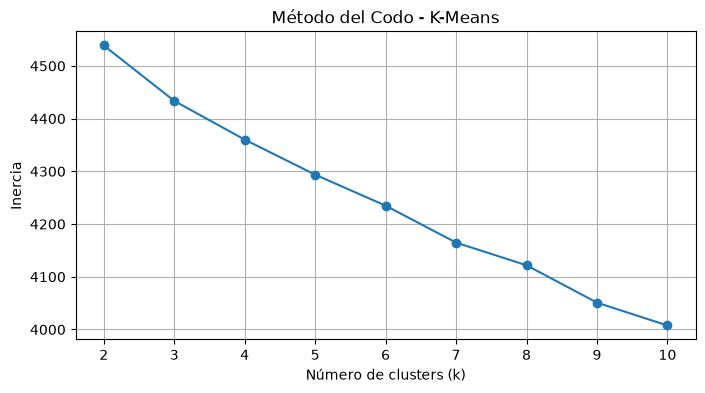

In [12]:
from sklearn.decomposition import TruncatedSVD

# Reducir dimensiones antes de K-Means
svd = TruncatedSVD(n_components=100, random_state=42)
matriz_reducida = svd.fit_transform(matriz_tfidf)
print(f"✅ Matriz reducida: {matriz_reducida.shape}")

inercias = []
rango = range(2, 11)

for k in rango:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(matriz_reducida)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(rango, inercias, marker='o')
plt.title('Método del Codo - K-Means')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show() 

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(matriz_densa)

print("✅ Clusters asignados")
print(df['cluster'].value_counts())

✅ Clusters asignados
cluster
4    16297
1     5601
3     5544
2     4425
0     3162
Name: count, dtype: int64


In [14]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(matriz_reducida)

print("✅ Clusters asignados")
print(df['cluster'].value_counts())

✅ Clusters asignados
cluster
1    15561
2     9894
3     4884
4     3159
0     1531
Name: count, dtype: int64


In [15]:
for i in range(5):
    print(f"\n🎬 Cluster {i}:")
    print(df[df['cluster'] == i][['title', 'genres', 'imdb_rating']].head(5).to_string())


🎬 Cluster 0:
                                title              genres  imdb_rating
14                 The Endless Summer         Documentary          7.6
54                 Land Without Bread         Documentary          7.3
88                      Gimme Shelter  Documentary, Music          7.8
90        Bob Dylan – Don't Look Back  Documentary, Music          7.9
167  Berlin: Symphony of a Great City         Documentary          7.6

🎬 Cluster 1:
                 title                         genres  imdb_rating
0                Ariel  Comedy, Drama, Romance, Crime          7.4
1  Shadows in Paradise         Comedy, Drama, Romance          7.4
2           Four Rooms                         Comedy          6.7
6         Forrest Gump         Comedy, Drama, Romance          8.8
7      American Beauty                          Drama          8.3

🎬 Cluster 2:
                title                     genres  imdb_rating
3      Judgment Night    Action, Crime, Thriller          6.6
10    

In [16]:
import pickle

# Guardar el modelo TF-IDF
with open('../src/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Guardar la matriz de similitud
with open('../src/similitud.pkl', 'wb') as f:
    pickle.dump(similitud, f)

# Guardar el modelo K-Means
with open('../src/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Guardar el dataset con clusters
df.to_csv('../data/processed/TMDB_clean.csv', index=False)

print("✅ Modelos guardados correctamente")

MemoryError: 

In [17]:
import pickle

# Guardar el modelo TF-IDF
with open('../src/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Guardar la matriz de similitud
with open('../src/similitud.pkl', 'wb') as f:
    pickle.dump(similitud, f)

# Guardar el modelo K-Means
with open('../src/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Guardar el dataset con clusters
df.to_csv('../data/processed/TMDB_clean.csv', index=False)

print("✅ Modelos guardados correctamente")

MemoryError: 

In [18]:
import pickle

# Guardar solo el modelo TF-IDF
with open('../src/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Guardar la matriz TF-IDF (mucho más pequeña)
with open('../src/matriz_tfidf.pkl', 'wb') as f:
    pickle.dump(matriz_tfidf, f)

# Guardar el modelo K-Means
with open('../src/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Guardar el dataset limpio con clusters
df.to_csv('../data/processed/TMDB_clean.csv', index=False)

print("✅ Modelos guardados correctamente")

✅ Modelos guardados correctamente
